**Part 1: [Data Preprocessing & Cleaning]**

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('mxmh_survey_results.csv')

# Irrelevant columns were dropped
df = df.drop(columns=['Timestamp', 'Permissions'], errors='ignore')

# Frequency columns are ordinally encoded - they capture per-genre listening
# patterns which are directly relevant to our research questions about genre and mental health
freq_order   = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Very frequently': 3}
freq_columns = [col for col in df.columns if 'Frequency' in col]
for col in freq_columns:
    df[col] = df[col].map(freq_order)

# BPM outliers are filtered first (the raw data contains a 1-billion entry data error)
df = df[(df['BPM'].isna()) | ((df['BPM'] > 30) & (df['BPM'] < 300))]

# Missing BPM values are imputed using each genre's median - preserves around 100 more rows vs. dropping
df['BPM'] = df.groupby('Fav genre')['BPM'].transform(lambda x: x.fillna(x.median()))

# Missing Age values are imputed with the overall median (only 1 row affected)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Rows missing the critical target variable or key analysis columns are dropped
df = df.dropna(subset=['Music effects', 'Hours per day', 'Depression', 'Insomnia', 'Anxiety', 'Fav genre'])

# Any remaining string-type missing values are filled in with the mode
for col in df.select_dtypes(include=['object']).columns:  # catches remaining string columns
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Data cleaned! Final shape: {df.shape[0]} rows, {df.shape[1]} columns.")
print(f"(Kept {df.shape[0]} of 736 original respondents - {736 - df.shape[0]} rows were removed)")

# Descriptive Statistics get printed here
print("\n--- Descriptive Statistics for Mental Health Scores ---")
print(df[['Anxiety', 'Depression', 'Insomnia', 'OCD']].describe().round(2))

print("\n--- Descriptive Statistics for Listening Habits ---")
print(df[['Hours per day', 'BPM', 'Age']].describe().round(2))

print("\n--- Music Effects Distribution ---")
print(df['Music effects'].value_counts())

df.to_csv('cleaned_mxmh_data.csv', index=False) #*The dataset is now cleaned and has been created in the "Files" sidebar to save for our records

Data cleaned! Final shape: 720 rows, 31 columns.
(Kept 720 of 736 original respondents - 16 rows were removed)

--- Descriptive Statistics for Mental Health Scores ---
       Anxiety  Depression  Insomnia     OCD
count   720.00      720.00    720.00  720.00
mean      5.83        4.78      3.74    2.64
std       2.79        3.02      3.08    2.84
min       0.00        0.00      0.00    0.00
25%       4.00        2.00      1.00    0.00
50%       6.00        5.00      3.00    2.00
75%       8.00        7.00      6.00    5.00
max      10.00       10.00     10.00   10.00

--- Descriptive Statistics for Listening Habits ---
       Hours per day     BPM     Age
count         720.00  720.00  720.00
mean            3.60  123.35   25.02
std             3.05   29.84   11.72
min             0.00   40.00   10.00
25%             2.00  105.00   18.00
50%             3.00  120.00   21.00
75%             5.00  140.00   27.00
max            24.00  220.00   89.00

--- Music Effects Distribution ---
Music

**Part 2: [EDA & Visualizations]**

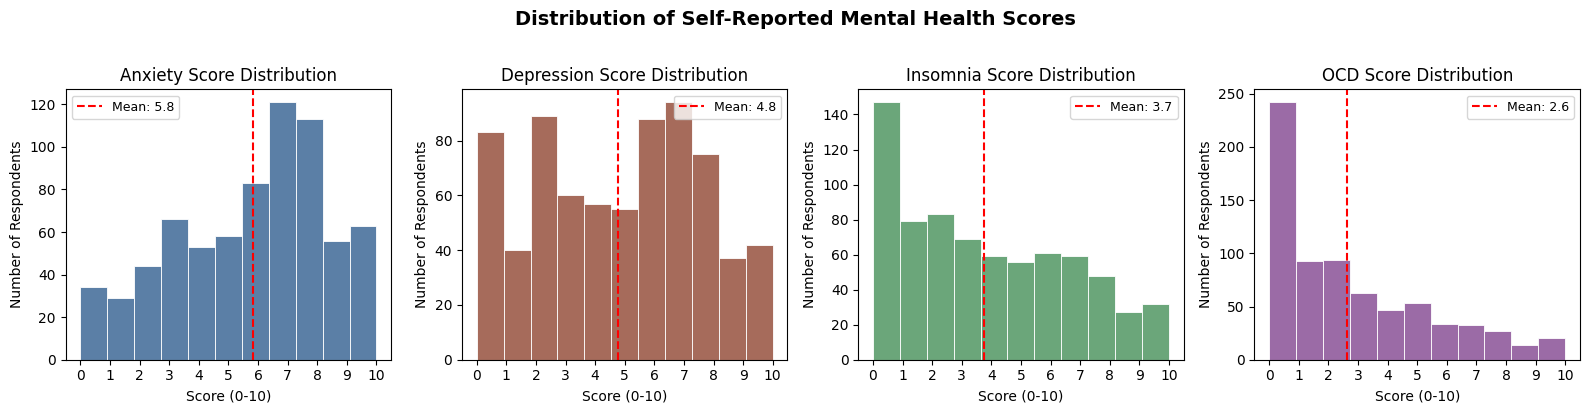

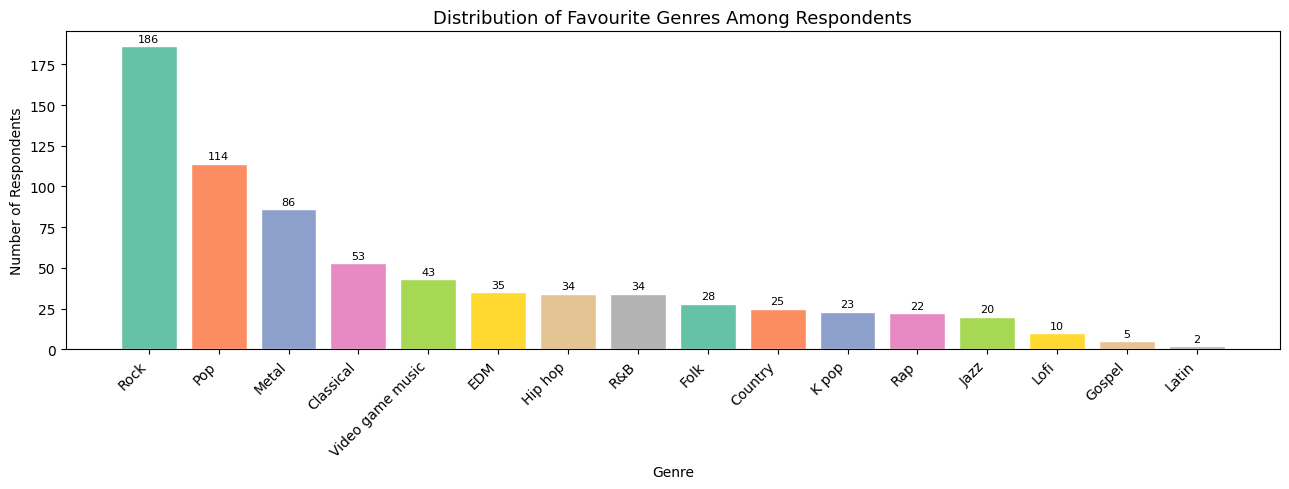

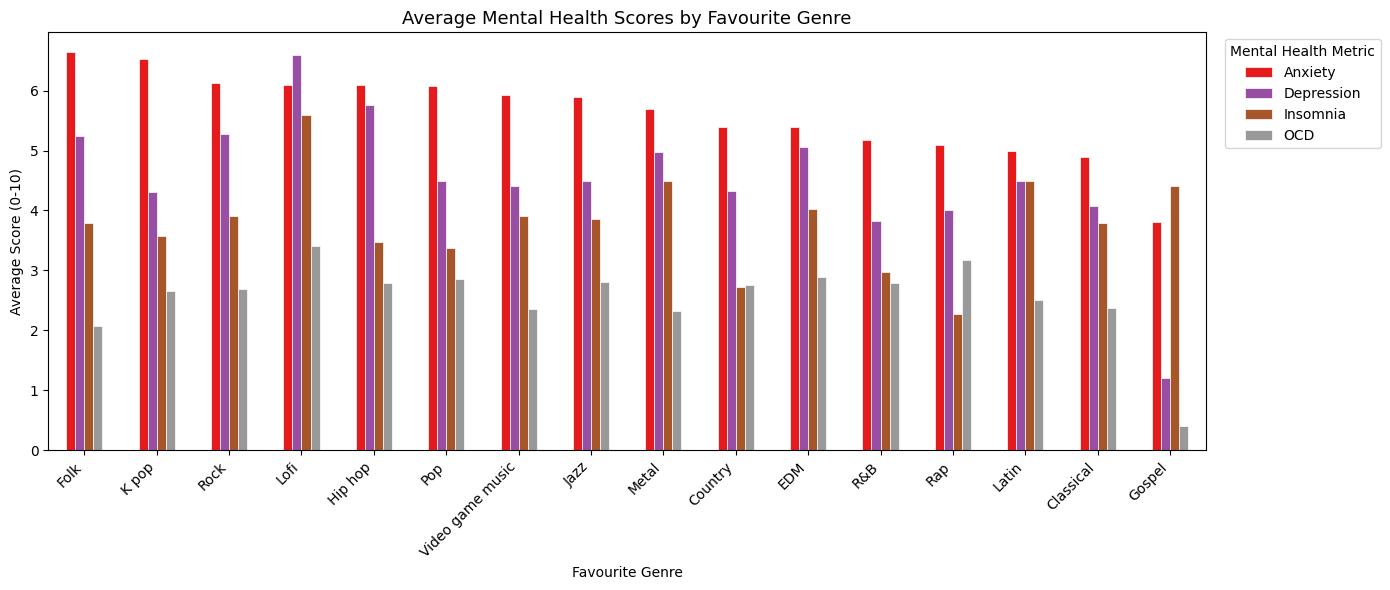

/tmp/ipykernel_18311/4065923886.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre_Type', y='Anxiety', data=df, order=intensity_order, palette='Set2')


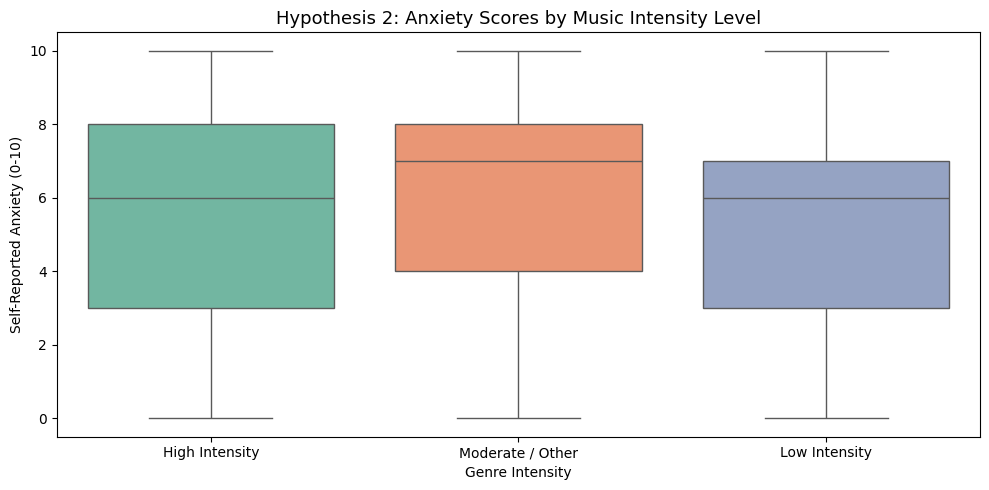

/tmp/ipykernel_18311/4065923886.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre_Type', y='Insomnia', data=df, order=intensity_order, palette='Set3')


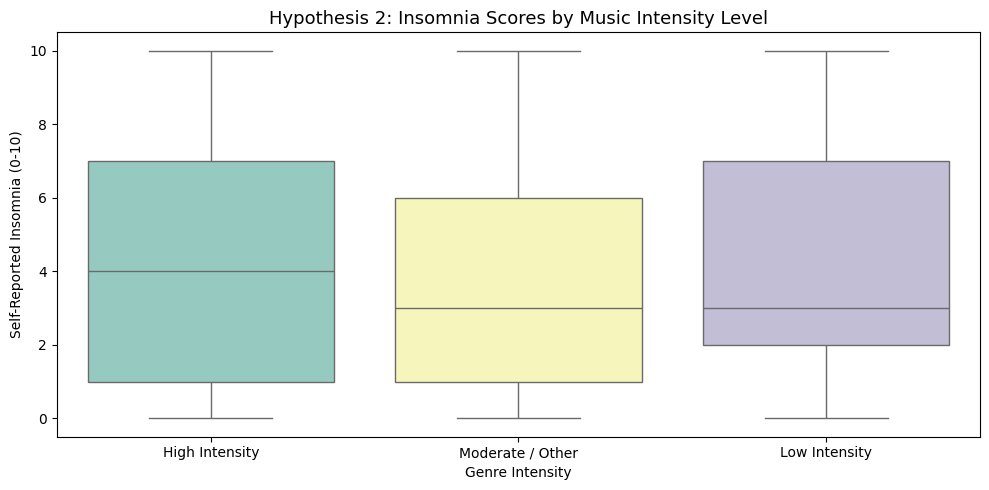

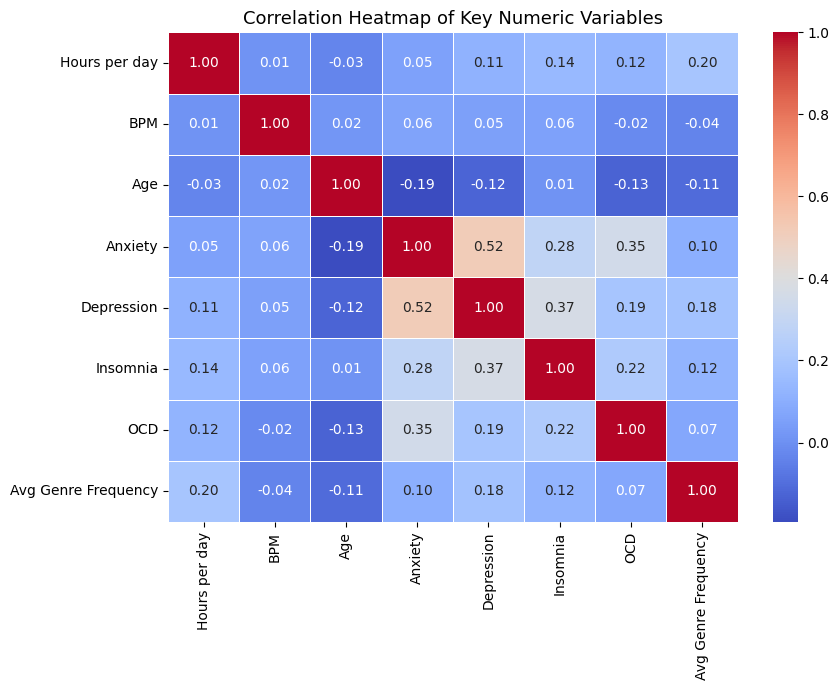

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Intensity groups defined are defined here
high_intensity = ['Metal', 'EDM', 'Rap', 'Hip hop']
low_intensity  = ['Classical', 'Jazz', 'Lofi']

def categorize_genre(genre):
    if genre in high_intensity: return 'High Intensity'
    elif genre in low_intensity: return 'Low Intensity'
    else: return 'Moderate / Other'

df['Genre_Type'] = df['Fav genre'].apply(categorize_genre)
intensity_order = ['High Intensity', 'Moderate / Other', 'Low Intensity']

# -- Graph 1: Distribution of Self-Reported Mental Health Scores
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
mental_cols = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
palette = ['#5B7FA6', '#A66B5B', '#6BA67A', '#9B6BA6']

for ax, col, color in zip(axes, mental_cols, palette):
    ax.hist(df[col], bins=11, range=(0, 10), color=color, edgecolor='white', linewidth=0.6)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.set_title(f'{col} Score Distribution')
    ax.set_xlabel('Score (0-10)')
    ax.set_ylabel('Number of Respondents')
    ax.set_xticks(range(0, 11))
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Self-Reported Mental Health Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# -- Graph 2: Respondent Genre Preferences
genre_counts = df['Fav genre'].value_counts()
plt.figure(figsize=(13, 5))
bars = plt.bar(genre_counts.index, genre_counts.values, color=sns.color_palette('Set2', len(genre_counts)), edgecolor='white')
plt.title('Distribution of Favourite Genres Among Respondents', fontsize=13)
plt.xlabel('Genre')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# -- Graph 3: Average Mental Health Scores by Favourite Genre
genre_avg = df.groupby('Fav genre')[['Anxiety', 'Depression', 'Insomnia', 'OCD']].mean().round(2)
genre_avg = genre_avg.sort_values('Anxiety', ascending=False)

genre_avg.plot(kind='bar', figsize=(14, 6), colormap='Set1', edgecolor='white', linewidth=0.5)
plt.title('Average Mental Health Scores by Favourite Genre', fontsize=13)
plt.xlabel('Favourite Genre')
plt.ylabel('Average Score (0-10)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mental Health Metric', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# -- Graph 4: Hypothesis 2 (Part 1) - Anxiety by Genre Intensity
plt.figure(figsize=(10, 5))
sns.boxplot(x='Genre_Type', y='Anxiety', data=df, order=intensity_order, palette='Set2')
plt.title('Hypothesis 2: Anxiety Scores by Music Intensity Level', fontsize=13)
plt.xlabel('Genre Intensity')
plt.ylabel('Self-Reported Anxiety (0-10)')
plt.tight_layout()
plt.show()

# -- Graph 5: Hypothesis 2 (Part 2) - Insomnia by Genre Intensity
plt.figure(figsize=(10, 5))
sns.boxplot(x='Genre_Type', y='Insomnia', data=df, order=intensity_order, palette='Set3')
plt.title('Hypothesis 2: Insomnia Scores by Music Intensity Level', fontsize=13)
plt.xlabel('Genre Intensity')
plt.ylabel('Self-Reported Insomnia (0-10)')
plt.tight_layout()
plt.show()

# -- Graph 6: Correlation Heatmap
# Average genre frequency is included as a summary engagement metric
freq_cols = [col for col in df.columns if 'Frequency' in col]
heatmap_df = df[['Hours per day', 'BPM', 'Age', 'Anxiety', 'Depression', 'Insomnia', 'OCD']].copy()
heatmap_df['Avg Genre Frequency'] = df[freq_cols].mean(axis=1)

plt.figure(figsize=(9, 7))
sns.heatmap(heatmap_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Key Numeric Variables', fontsize=13)
plt.tight_layout()
plt.show()

**Part 3: [Regression, Correlation & Hypothesis Testing]**

-- Hypothesis 1: Hours per Day vs. Depression
Polynomial Regression R²: 0.0224
(The model explains 2.24% of the variance in Depression scores)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


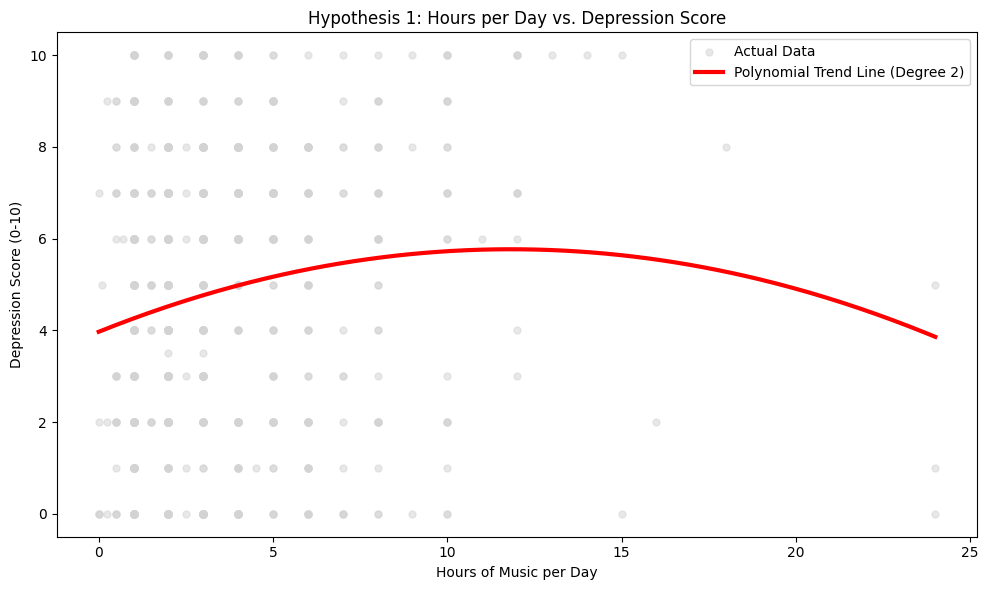


-- Hypothesis 3: BPM vs. Insomnia
Pearson r: 0.0580
P-value: 0.1202
Result: No statistically significant association found (p ≥ 0.05)


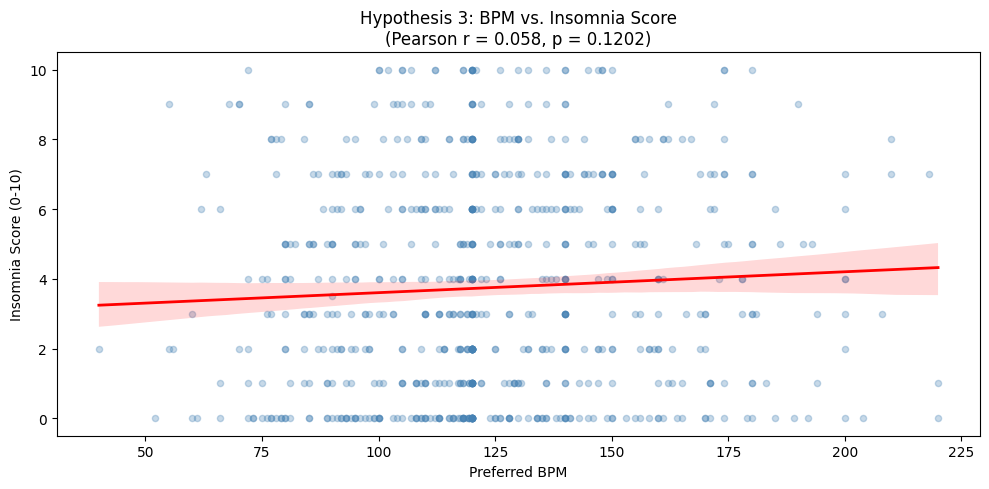


-- One-Way ANOVA: Genre Intensity vs. Anxiety 
F-statistic: 3.0531   P-value: 0.0478
Result: Significant difference in anxiety across intensity groups (p < 0.05)

-- One-Way ANOVA: Genre Intensity vs. Insomnia 
F-statistic: 1.0199   P-value: 0.3612
Result: No significant difference detected (p ≥ 0.05)


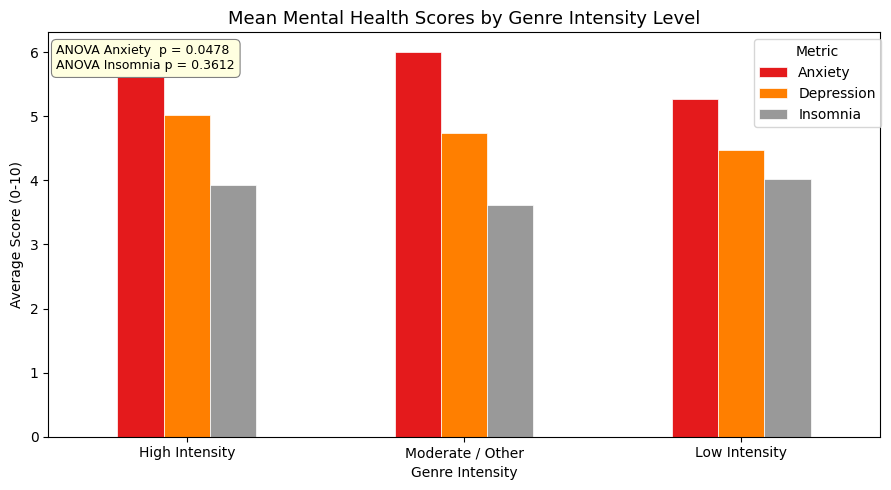

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy import stats

intensity_order = ['High Intensity', 'Moderate / Other', 'Low Intensity']

# -- Hypothesis 1: Polynomial Regression - Hours per Day vs. Depression
X_reg = df[['Hours per day']]
y_reg = df['Depression']

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_reg)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_reg)
r2 = poly_model.score(X_poly, y_reg)

print("-- Hypothesis 1: Hours per Day vs. Depression")
print(f"Polynomial Regression R²: {r2:.4f}")
print(f"(The model explains {r2*100:.2f}% of the variance in Depression scores)")

# Graph 7: Polynomial regression curve - Hours vs Depression
plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, color='lightgray', alpha=0.5, label='Actual Data', s=25)
X_curve = np.linspace(X_reg.min().values[0], X_reg.max().values[0], 300).reshape(-1, 1)
y_curve = poly_model.predict(poly.transform(X_curve))
plt.plot(X_curve, y_curve, color='red', linewidth=3, label='Polynomial Trend Line (Degree 2)')
plt.title('Hypothesis 1: Hours per Day vs. Depression Score', fontsize=12)
plt.xlabel('Hours of Music per Day')
plt.ylabel('Depression Score (0-10)')
plt.legend()
plt.tight_layout()
plt.show()

# -- Hypothesis 3: Pearson Correlation - BPM vs. Insomnia
corr_r, corr_p = stats.pearsonr(df['BPM'], df['Insomnia'])

print("\n-- Hypothesis 3: BPM vs. Insomnia") #*Mini table to display in the output to get a clear visual of the details
print(f"Pearson r: {corr_r:.4f}")
print(f"P-value: {corr_p:.4f}")
print("Result:", "Statistically significant association detected (p < 0.05)" if corr_p < 0.05
                 else "No statistically significant association found (p ≥ 0.05)")

# Graph 8: BPM vs Insomnia - scatter with linear regression line and 95% CI band
plt.figure(figsize=(10, 5))
sns.regplot(x='BPM', y='Insomnia', data=df, scatter_kws={'alpha': 0.3, 'color': 'steelblue', 's': 20}, line_kws={'color': 'red', 'linewidth': 2}, ci=95)
plt.title(f'Hypothesis 3: BPM vs. Insomnia Score\n(Pearson r = {corr_r:.3f}, p = {corr_p:.4f})', fontsize=12)
plt.xlabel('Preferred BPM')
plt.ylabel('Insomnia Score (0-10)')
plt.tight_layout()
plt.show()

# -- Statistical Hypothesis Testing: One-Way ANOVA
print("\n-- One-Way ANOVA: Genre Intensity vs. Anxiety ") #*Mini table to display in the output to get a clear visual of the details (prior to graph)
groups_anx = [df[df['Genre_Type'] == g]['Anxiety']  for g in intensity_order]
f_anx, p_anx = stats.f_oneway(*groups_anx)
print(f"F-statistic: {f_anx:.4f}   P-value: {p_anx:.4f}")
print("Result:", "Significant difference in anxiety across intensity groups (p < 0.05)" if p_anx < 0.05 else "No significant difference detected (p ≥ 0.05)")

print("\n-- One-Way ANOVA: Genre Intensity vs. Insomnia ") #*Mini table to display in the output to get a clear visual of the details (prior to graph)
groups_ins = [df[df['Genre_Type'] == g]['Insomnia'] for g in intensity_order]
f_ins, p_ins = stats.f_oneway(*groups_ins)
print(f"F-statistic: {f_ins:.4f}   P-value: {p_ins:.4f}")
print("Result:", "Significant difference in insomnia across intensity groups (p < 0.05)" if p_ins < 0.05 else "No significant difference detected (p ≥ 0.05)")

# Graph 9: Mean mental health scores by genre intensity - grouped bar with ANOVA annotations
intensity_means = df.groupby('Genre_Type')[['Anxiety', 'Depression', 'Insomnia']].mean().loc[intensity_order]
ax = intensity_means.plot(kind='bar', figsize=(9, 5), colormap='Set1', edgecolor='white', linewidth=0.5)
plt.title('Mean Mental Health Scores by Genre Intensity Level', fontsize=13)
plt.xlabel('Genre Intensity')
plt.ylabel('Average Score (0-10)')
plt.xticks(rotation=0)
plt.legend(title='Metric', bbox_to_anchor=(1.01, 1))
plt.text(0.01, 0.97, f'ANOVA Anxiety  p = {p_anx:.4f}\nANOVA Insomnia p = {p_ins:.4f}', transform=ax.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', linewidth=0.8))
plt.tight_layout()
plt.show()

**Part 4: [Classification Models & Feature Importance]**

-- Target Variable Distribution
  Improve (1):            536 respondents (74.4%)
  Worsen / No Effect (0): 184 respondents (25.6%)
  Class imbalance ratio:  2.91x → handled via class_weight='balanced'

------ Model Performance on Holdout Test Set (+ 5-Fold CV F1) -------
Model                   Accuracy  Precision   Recall       F1     CV F1 ± SD
----------------------------------------------------------------------------
Logistic Regression        0.549      0.769    0.561    0.649   0.630 ± 0.050
Decision Tree              0.583      0.776    0.617    0.688   0.735 ± 0.063
KNN                        0.743      0.750    0.981    0.850   0.835 ± 0.010
Random Forest              0.757      0.754    1.000    0.859   0.851 ± 0.003


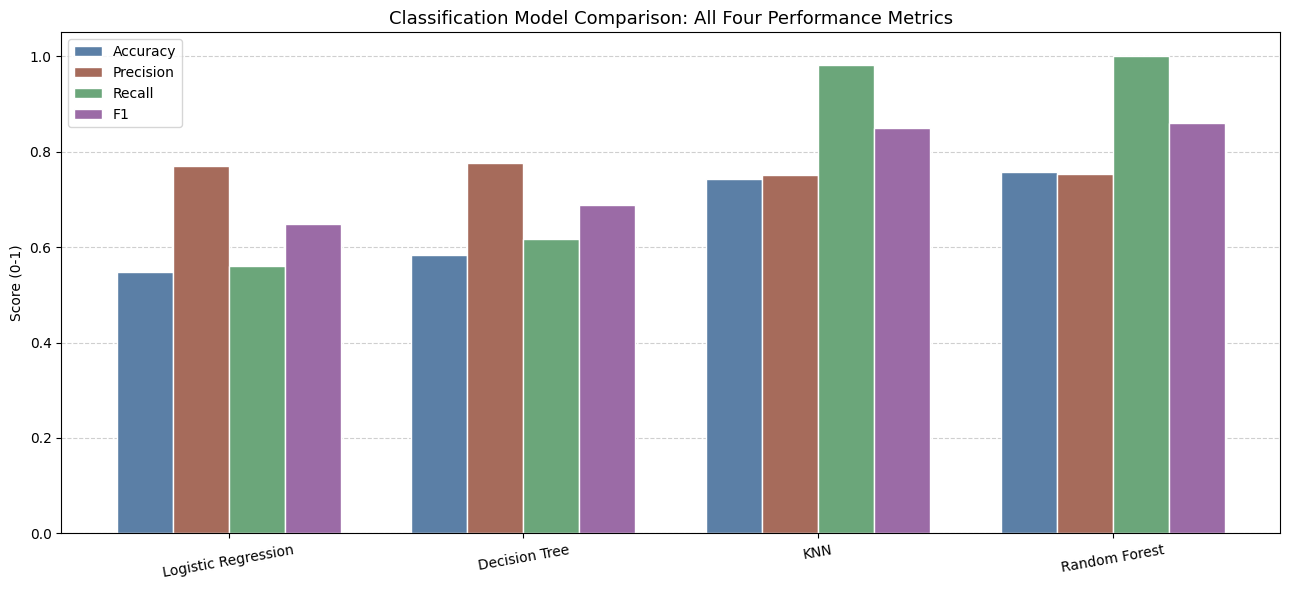

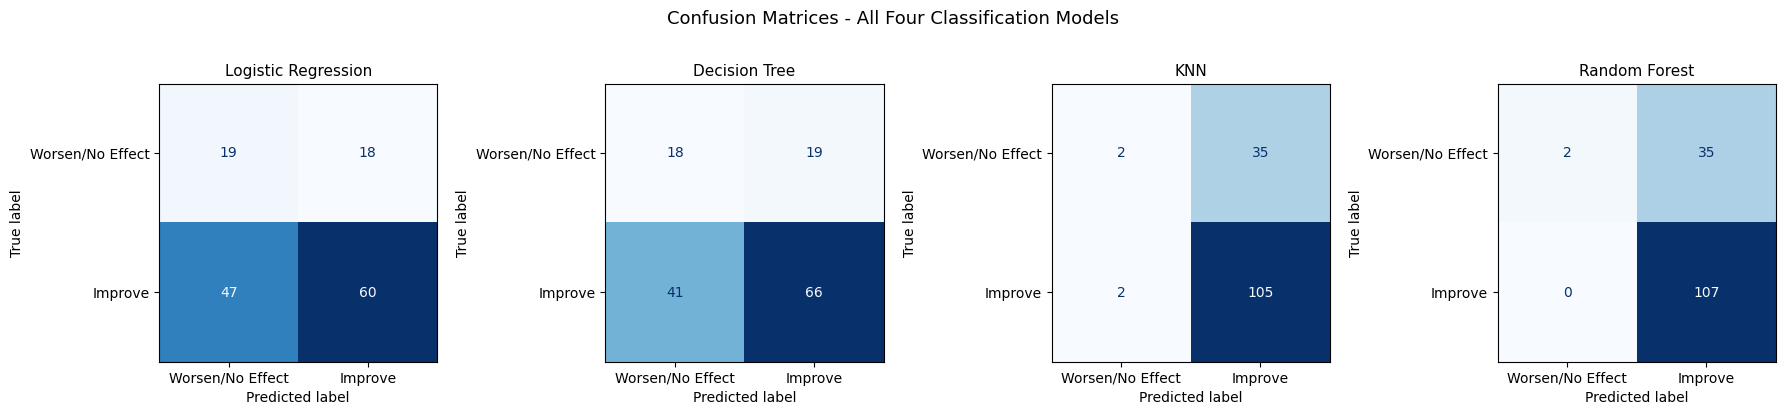

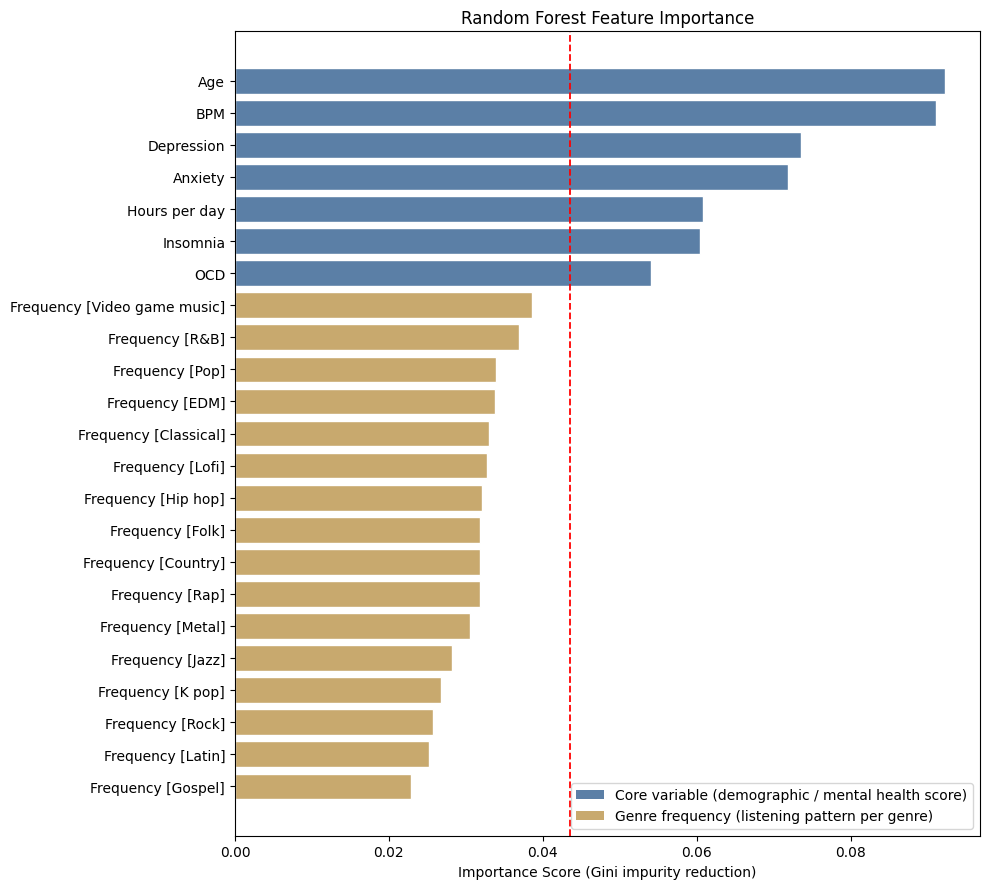


-- Best Performing Model: Random Forest 
   F1-Score (holdout test): 0.859
   CV F1 (5-fold):          0.851 ± 0.003
   F1 is used as the primary metric due to class imbalance in the target variable.

-- Top 5 Predictive Features (Random Forest)
   Age                                      0.0922
   BPM                                      0.0911
   Depression                               0.0736
   Anxiety                                  0.0718
   Hours per day                            0.0608


In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)
from matplotlib.patches import Patch

# Target variable mapped here - Improve = 1, Worsen/No effect = 0
df['Target_Effect'] = df['Music effects'].apply(lambda x: 1 if x == 'Improve' else 0)

counts = df['Target_Effect'].value_counts()
print("-- Target Variable Distribution")
print(f"  Improve (1):            {counts[1]} respondents ({counts[1]/len(df)*100:.1f}%)")
print(f"  Worsen / No Effect (0): {counts[0]} respondents ({counts[0]/len(df)*100:.1f}%)")
print(f"  Class imbalance ratio:  {counts[1]/counts[0]:.2f}x → handled via class_weight='balanced'")

# Feature set includes both core numeric variables AND the encoded per-genre frequency columns
freq_cols = [col for col in df.columns if 'Frequency' in col]
base_features = ['Hours per day', 'BPM', 'Age', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
features = base_features + freq_cols

X = df[features]
y = df['Target_Effect']

# Train-Test Split is stratified to preserve the class ratio in both sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling applied - required for Logistic Regression and KNN to work correctly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# All 4 classifiers defined here
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=9),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
}

# Stratified 5-Fold cross-validation is used alongside the holdout test for more reliable performance estimates
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("\n------ Model Performance on Holdout Test Set (+ 5-Fold CV F1) -------")
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'CV F1 ± SD':>14}")
print("-" * 76)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='f1')
    cv_mean, cv_std = cv_scores.mean(), cv_scores.std()

    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1,
        'CV F1': cv_mean, 'CV Std': cv_std, 'model': model, 'y_pred': y_pred
    }
    print(f"{name:<22} {acc:>9.3f} {prec:>10.3f} {rec:>8.3f} {f1:>8.3f}   {cv_mean:.3f} ± {cv_std:.3f}")

# -- Graph 10: Model Comparison Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.19
metric_colors = ['#5B7FA6', '#A66B5B', '#6BA67A', '#9B6BA6']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = [results[m][metric] for m in model_names]
    ax.bar(x + i * width, vals, width, label=metric, color=color, edgecolor='white')

ax.set_title('Classification Model Comparison: All Four Performance Metrics', fontsize=13)
ax.set_ylabel('Score (0-1)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=10)
ax.set_ylim(0, 1.05)
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# -- Graph 11: Confusion Matrices for All 4 Models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Worsen/No Effect', 'Improve'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)
plt.suptitle('Confusion Matrices - All Four Classification Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# -- Graph 12: Random Forest Feature Importance
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
bar_colors = ['#5B7FA6' if f in base_features else '#C8A96E' for f in importances.index]

plt.figure(figsize=(10, 9))
plt.barh(importances.index, importances.values, color=bar_colors, edgecolor='white')
plt.axvline(importances.mean(), color='red', linestyle='--', linewidth=1.3, label=f'Mean importance: {importances.mean():.4f}')
plt.title("Random Forest Feature Importance", fontsize=12)
plt.xlabel('Importance Score (Gini impurity reduction)')
legend_elements = [
    Patch(facecolor='#5B7FA6', label='Core variable (demographic / mental health score)'),
    Patch(facecolor='#C8A96E', label='Genre frequency (listening pattern per genre)')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# Best model summary and top predictors get printed here
best = max(results, key=lambda m: results[m]['F1'])
print(f"\n-- Best Performing Model: {best} ") #*Mini table to display the best performing model
print(f"   F1-Score (holdout test): {results[best]['F1']:.3f}")
print(f"   CV F1 (5-fold):          {results[best]['CV F1']:.3f} ± {results[best]['CV Std']:.3f}")
print("   F1 is used as the primary metric due to class imbalance in the target variable.")
print("\n-- Top 5 Predictive Features (Random Forest)")
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f"   {feat:<40} {imp:.4f}")